# Proyecto Final Minería
## Fase 1 - Exploración profunda + formulación

Gerardo Andre Fernandez Cruz 23763 

José Gerardo Ruiz García 23719 

Melisa Dayana Mendizabal Meléndez 23778 

Renato Manuel Rojas Roldan 23813 

In [34]:
%matplotlib inline
import pandas as pd 

df = pd.read_csv("data_1777144519.csv", sep=";")
print(df)




                                             indicator País__ESTANDAR   
0    Personas usuarias de Internet por grupo etario...      Argentina  \
1    Personas usuarias de Internet por grupo etario...      Argentina   
2    Personas usuarias de Internet por grupo etario...      Argentina   
3    Personas usuarias de Internet por grupo etario...      Argentina   
4    Personas usuarias de Internet por grupo etario...      Argentina   
..                                                 ...            ...   
865  Personas usuarias de Internet por grupo etario...        Uruguay   
866  Personas usuarias de Internet por grupo etario...        Uruguay   
867  Personas usuarias de Internet por grupo etario...        Uruguay   
868  Personas usuarias de Internet por grupo etario...        Uruguay   
869  Personas usuarias de Internet por grupo etario...        Uruguay   

    Grupos etarios Uso Internet  Años__ESTANDAR  value   
0    edad de medicion a 17 años            2016     76  \
1    ed

In [35]:
resumen = df.describe()
print(resumen)



       Años__ESTANDAR       value  notes_ids  source_id
count      870.000000  870.000000        0.0      870.0
mean      2014.544828   44.858621        NaN     9353.0
std          4.712170   27.806615        NaN        0.0
min       2000.000000    0.000000        NaN     9353.0
25%       2011.000000   19.250000        NaN     9353.0
50%       2015.000000   45.000000        NaN     9353.0
75%       2018.000000   69.000000        NaN     9353.0
max       2022.000000   97.000000        NaN     9353.0


  EDA COMPLETO — USO DE INTERNET POR GRUPO ETARIO (ALC)

▶  DIMENSIONES DEL DATASET
   Filas     : 870
   Columnas  : 8

▶  NOMBRES Y TIPOS DE COLUMNAS (ORIGINALES)
indicator                       object
País__ESTANDAR                  object
Grupos etarios Uso Internet     object
Años__ESTANDAR                   int64
value                            int64
unit                            object
notes_ids                      float64
source_id                        int64

▶  VALORES NULOS POR COLUMNA
                               dtype  nulos  % nulos
indicator                     object      0      0.0
País__ESTANDAR                object      0      0.0
Grupos etarios Uso Internet   object      0      0.0
Años__ESTANDAR                 int64      0      0.0
value                          int64      0      0.0
unit                          object      0      0.0
notes_ids                    float64    870    100.0
source_id                      int64      0      0.0

▶  VALORES DUPL

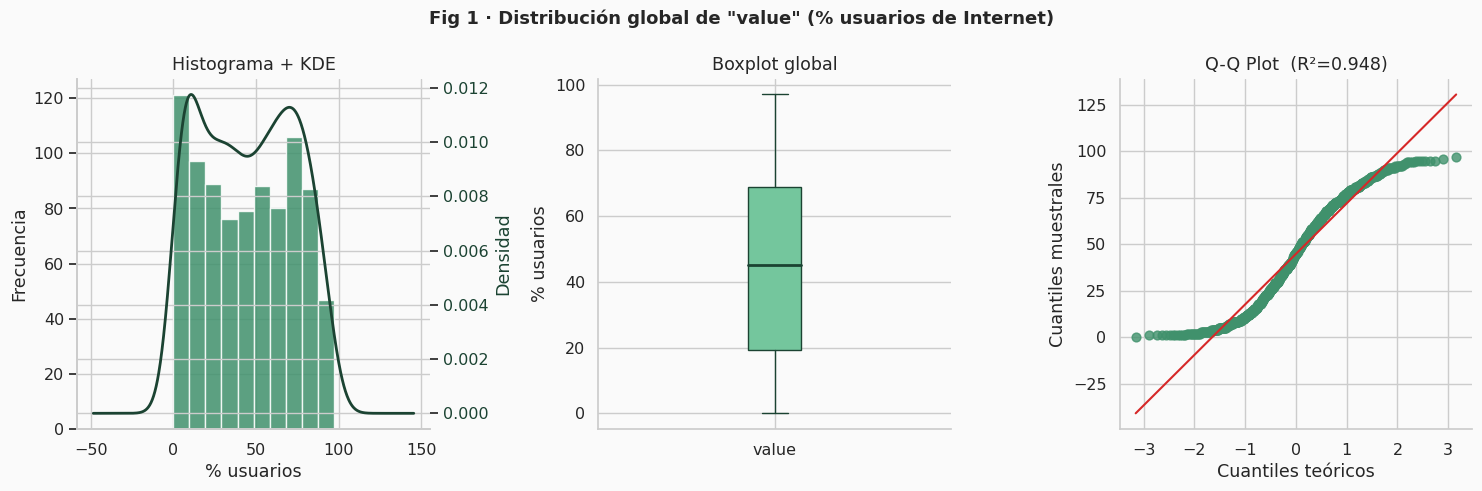

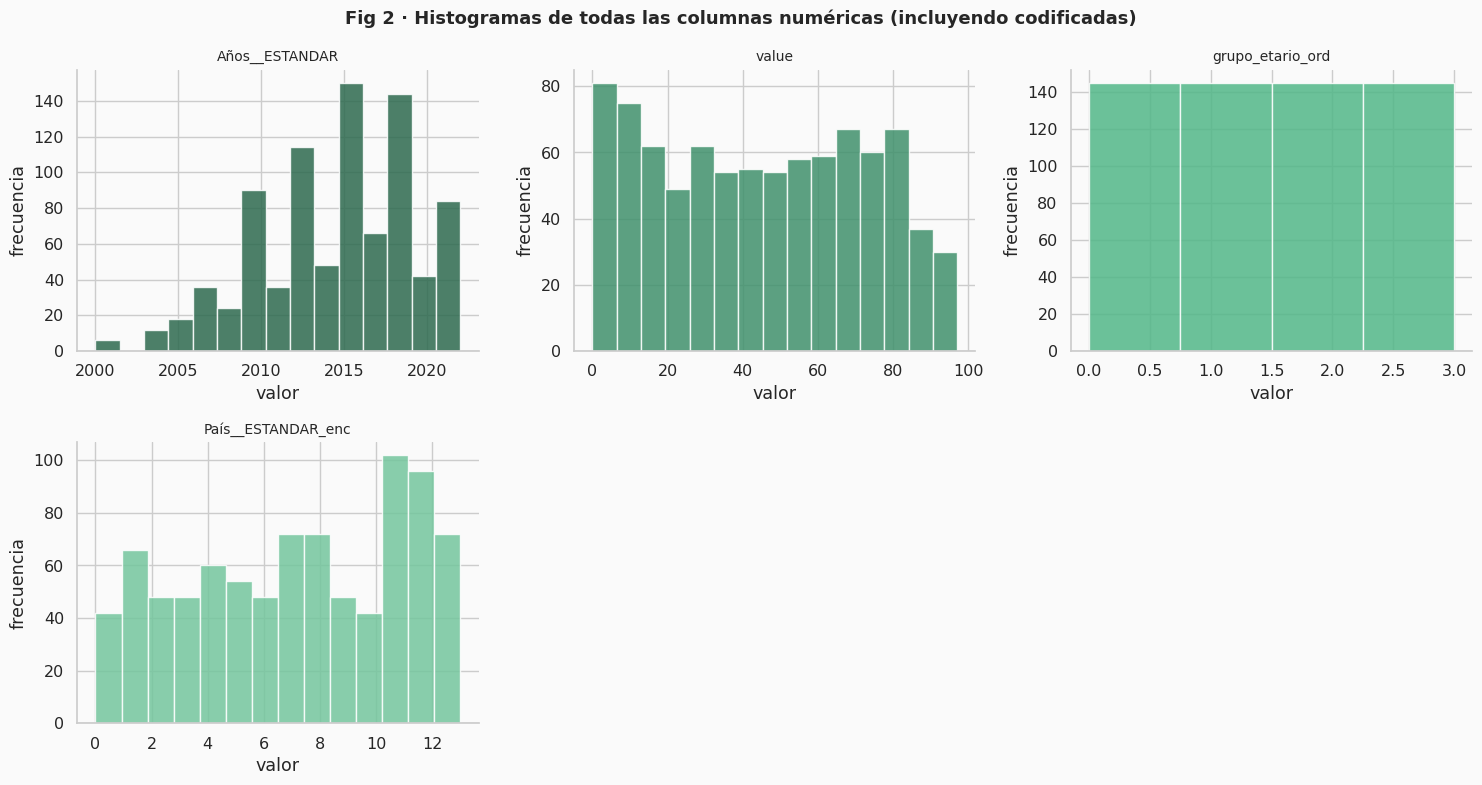

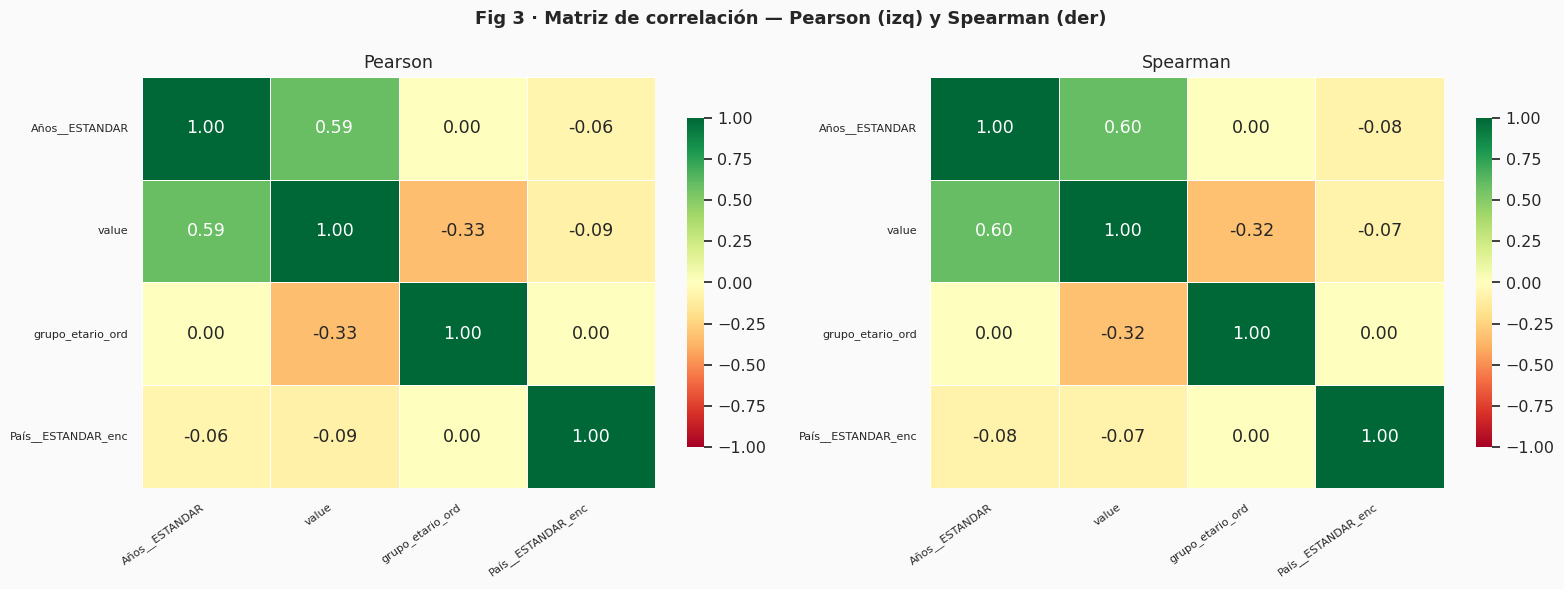

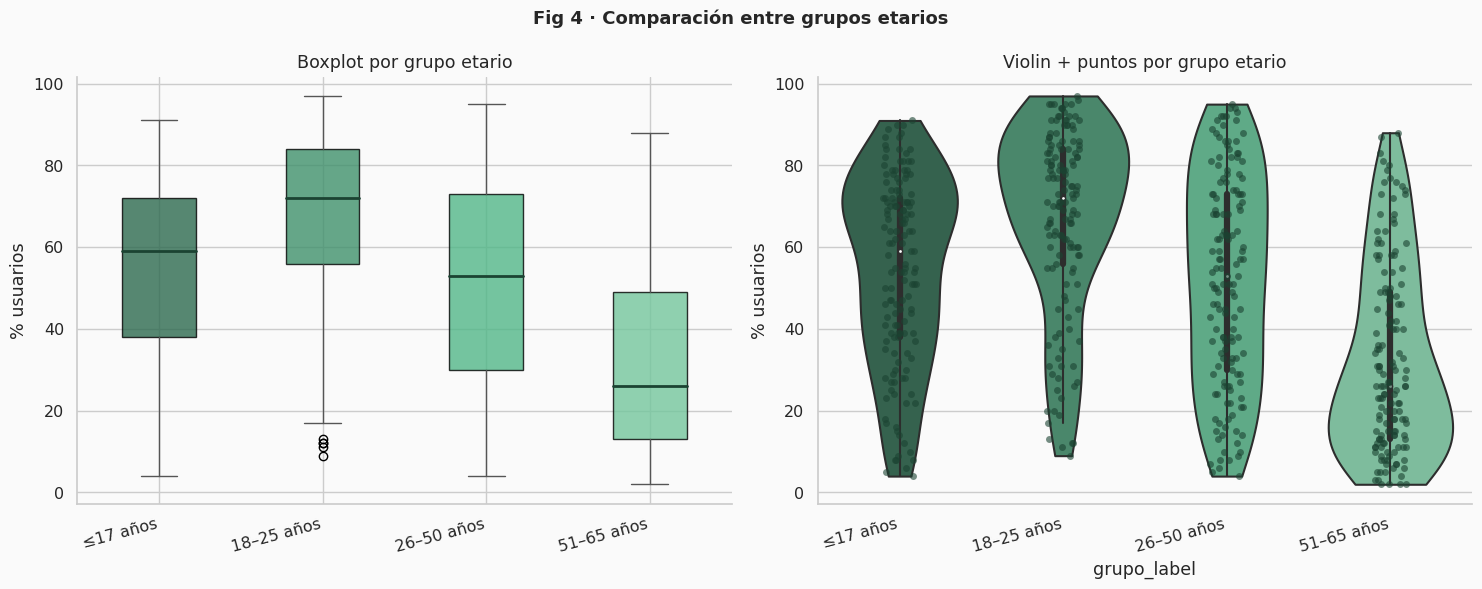

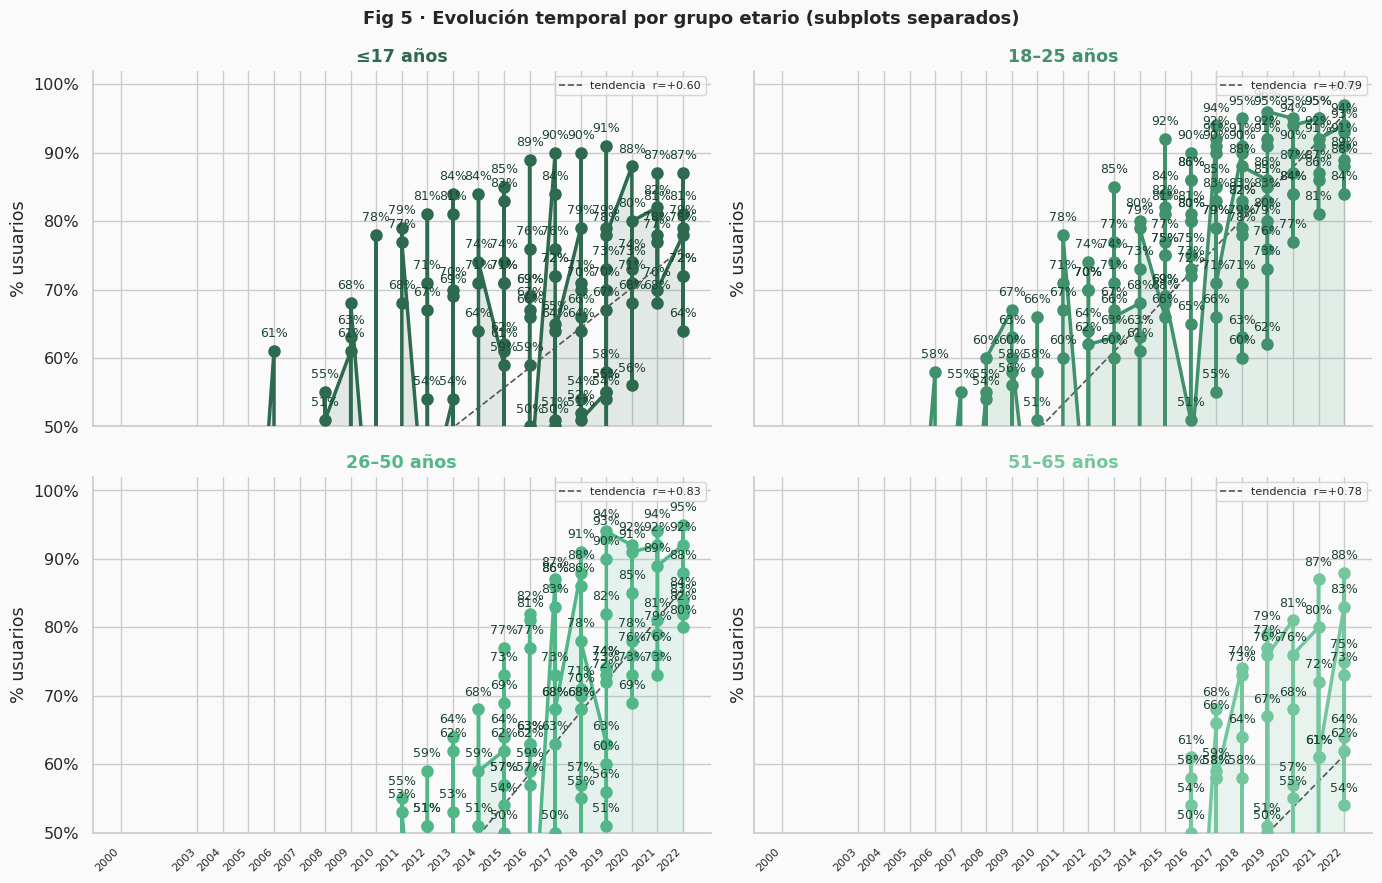

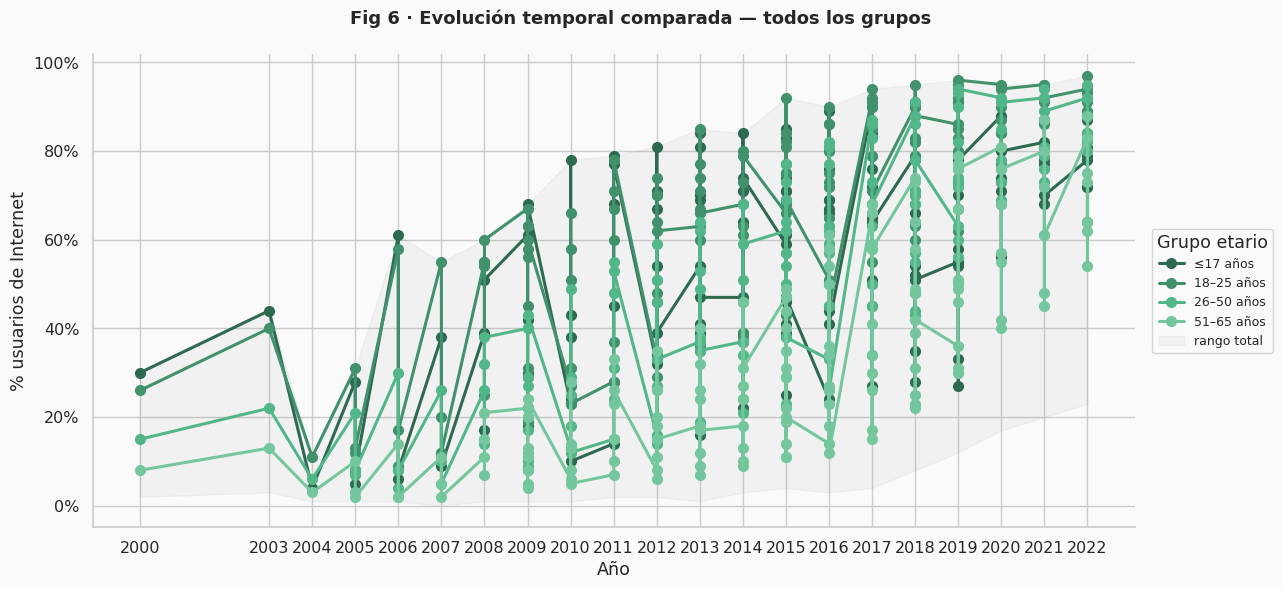

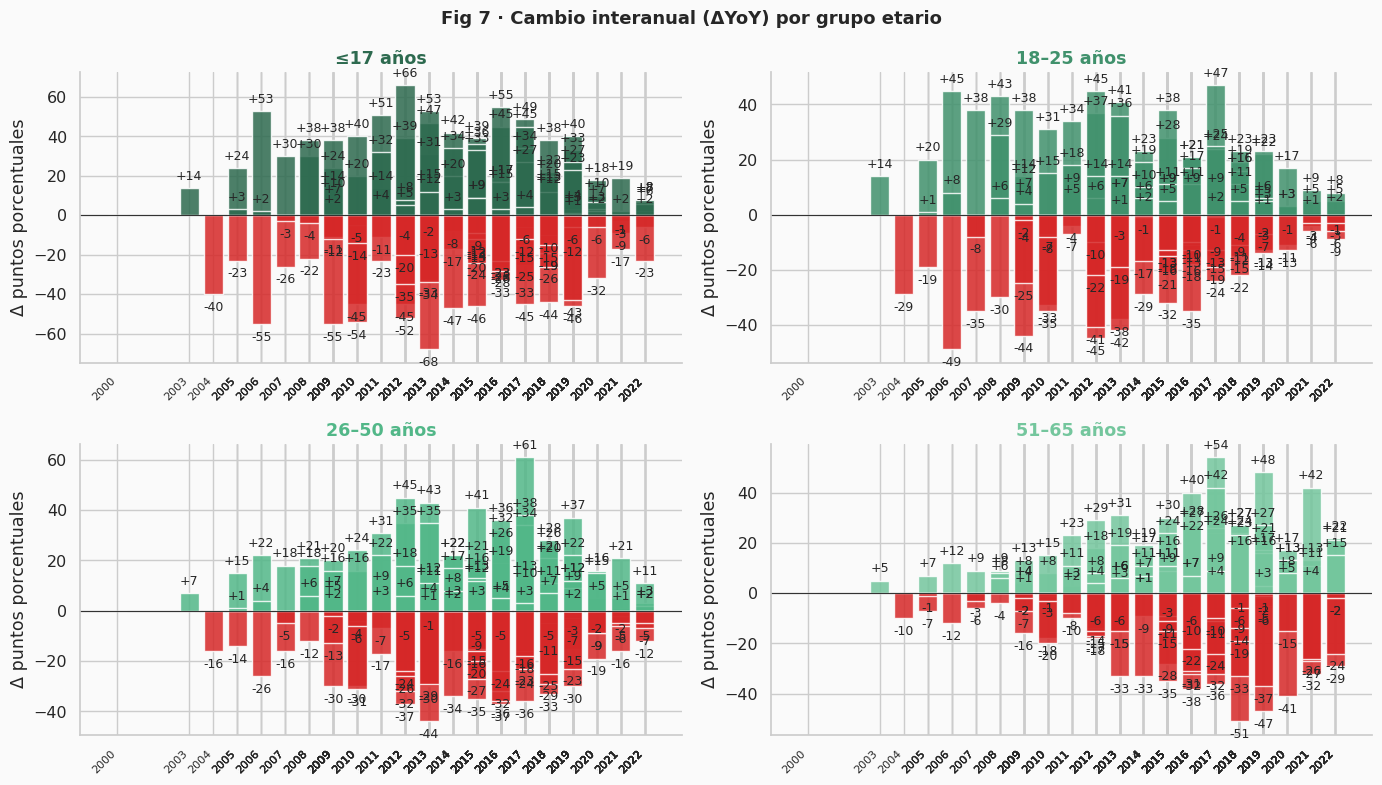

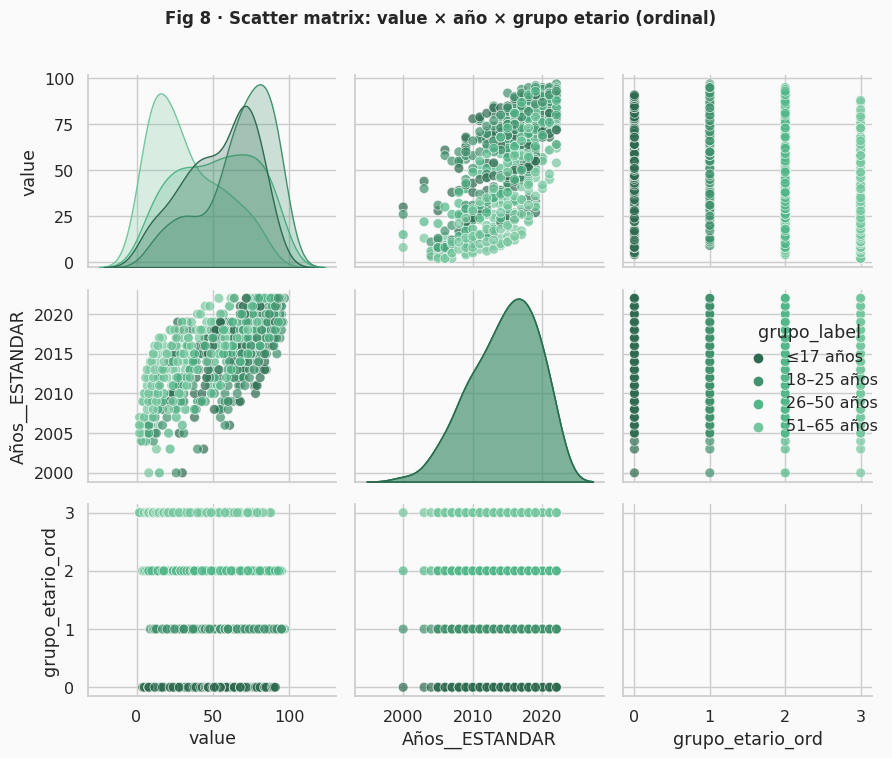

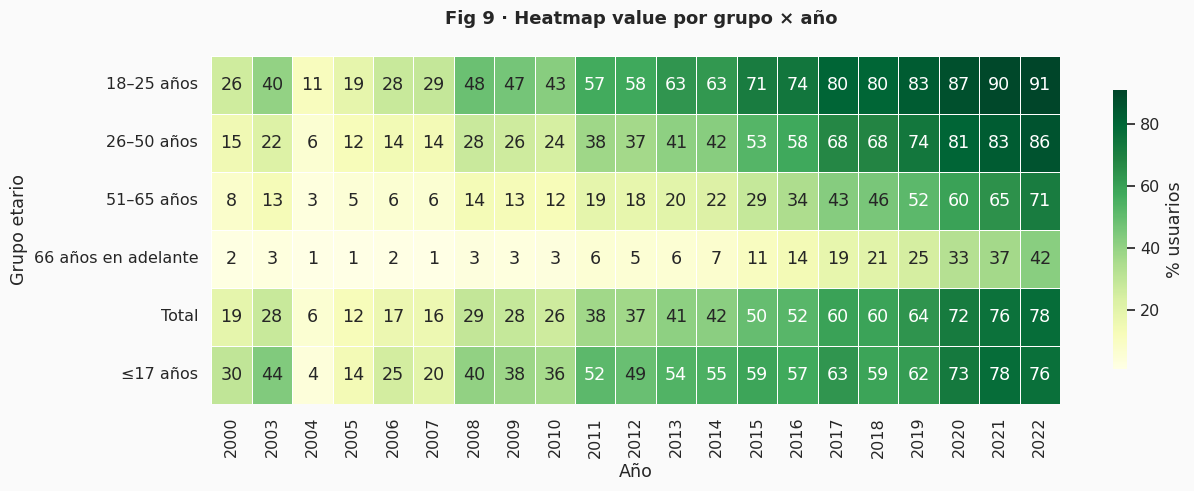

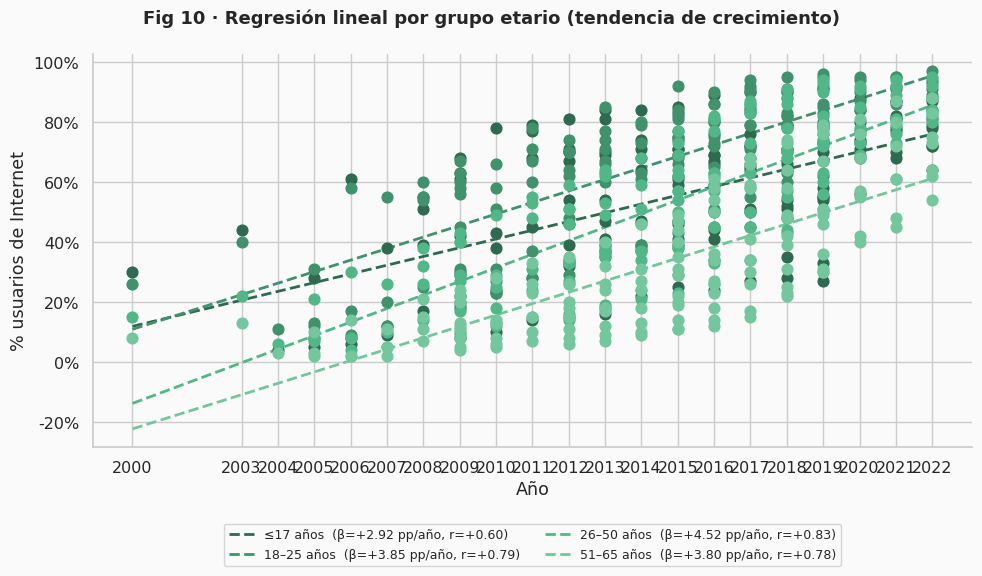


  FIN DEL EDA  — 10 figuras generadas


In [36]:
"""
EDA COMPLETO — Personas usuarias de Internet por grupo etario
América Latina y el Caribe
Incluye: codificación de categóricas, análisis de todas las columnas,
         correlaciones cruzadas y visualizaciones separadas por grupo.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ─── CONFIGURACIÓN VISUAL ─────────────────────────────────────────────────────
PALETTE = ['#2D6A4F', '#40916C', '#52B788', '#74C69D', '#95D5B2', '#B7E4C7']
ACCENT  = '#D62828'
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})

# ─── HELPERS ──────────────────────────────────────────────────────────────────
SEP = "=" * 68

def titulo(texto):
    print(f"\n▶  {texto}")

# ─── 1. CARGA ──────────────────────────────────────────────────────────────────


print(SEP)
print("  EDA COMPLETO — USO DE INTERNET POR GRUPO ETARIO (ALC)")
print(SEP)

# ─── 2. DIMENSIONES ───────────────────────────────────────────────────────────
titulo("DIMENSIONES DEL DATASET")
print(f"   Filas     : {df.shape[0]}")
print(f"   Columnas  : {df.shape[1]}")

# ─── 3. NOMBRES Y TIPOS ORIGINALES ────────────────────────────────────────────
titulo("NOMBRES Y TIPOS DE COLUMNAS (ORIGINALES)")
print(df.dtypes.to_string())

# ─── 4. VALORES NULOS ─────────────────────────────────────────────────────────
titulo("VALORES NULOS POR COLUMNA")
null_df = pd.DataFrame({
    'dtype':   df.dtypes,
    'nulos':   df.isnull().sum(),
    '% nulos': (df.isnull().sum() / len(df) * 100).round(2)
})
print(null_df.to_string())

# ─── 5. DUPLICADOS ────────────────────────────────────────────────────────────
titulo("VALORES DUPLICADOS")
print(f"   Filas completamente duplicadas: {df.duplicated().sum()}")

# ─── 6. CARDINALIDAD DE COLUMNAS CATEGÓRICAS ──────────────────────────────────
titulo("CARDINALIDAD DE COLUMNAS CATEGÓRICAS")
for col in df.select_dtypes(include='object').columns:
    vals = df[col].dropna().unique()
    print(f"\n   [{col}]  →  {len(vals)} valor/es único/s")
    for v in vals:
        print(f"      • {v}")

# ─── 7. RANGO TEMPORAL ────────────────────────────────────────────────────────
titulo("RANGO TEMPORAL")
print(f"   Años presentes : {sorted(df['Años__ESTANDAR'].unique())}")
print(f"   Año mín / máx  : {df['Años__ESTANDAR'].min()} – {df['Años__ESTANDAR'].max()}")
print(f"   Años cubiertos : {df['Años__ESTANDAR'].nunique()}")

# ─── 8. PRIMERAS Y ÚLTIMAS FILAS ──────────────────────────────────────────────
titulo("PRIMERAS FILAS")
print(df.head(5).to_string())
titulo("ÚLTIMAS FILAS")
print(df.tail(3).to_string())

# ══════════════════════════════════════════════════════════════════════════════
#  CODIFICACIÓN DE COLUMNAS CATEGÓRICAS
# ══════════════════════════════════════════════════════════════════════════════
titulo("CODIFICACIÓN DE COLUMNAS CATEGÓRICAS → NUMÉRICAS")

# ── a) Columnas constantes: se codifican con LabelEncoder pero no aportan varianza
from sklearn.preprocessing import LabelEncoder

df_enc = df.copy()
label_cols = ['indicator', 'País__ESTANDAR', 'unit']
for col in label_cols:
    le = LabelEncoder()
    df_enc[col + '_enc'] = le.fit_transform(df_enc[col].astype(str))
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"\n   {col}  →  {col}_enc")
    for k, v in mapping.items():
        print(f"      '{k}'  →  {v}")

# ── b) Grupo etario: codificación ORDINAL por rango de edad real
orden_grupos = {
    'edad de medicion a 17 años': 0,
    '18 a 25 años de edad':        1,
    '26 a 50 años de edad':        2,
    '51 a 65 años':                3,
}
df_enc['grupo_etario_ord'] = df_enc['Grupos etarios Uso Internet'].map(orden_grupos)
print("\n   Grupos etarios Uso Internet  →  grupo_etario_ord  (ordinal por edad)")
for k, v in sorted(orden_grupos.items(), key=lambda x: x[1]):
    print(f"      '{k}'  →  {v}")

# ── c) notes_ids: 100% nula, se rellena con -1 para tenerla presente
df_enc['notes_ids_fill'] = df_enc['notes_ids'].fillna(-1).astype(int)
print("\n   notes_ids  →  notes_ids_fill  (NaN → -1, columna completamente nula)")

titulo("DATASET CODIFICADO — PRIMERAS FILAS (columnas nuevas)")
nuevas = [c for c in df_enc.columns if '_enc' in c or '_ord' in c or '_fill' in c]
print(df_enc[['Años__ESTANDAR', 'value'] + nuevas].head(8).to_string())

titulo("TIPOS TRAS CODIFICACIÓN")
print(df_enc.dtypes.to_string())

# ══════════════════════════════════════════════════════════════════════════════
#  COLUMNAS NUMÉRICAS DISPONIBLES PARA ANÁLISIS
# ══════════════════════════════════════════════════════════════════════════════
num_cols = ['Años__ESTANDAR', 'value', 'source_id',
            'grupo_etario_ord', 'indicator_enc', 'País__ESTANDAR_enc', 'unit_enc',
            'notes_ids_fill']
# Descartamos las que son constantes puras para estadísticas descriptivas
var_cols = [c for c in num_cols if df_enc[c].nunique() > 1]

titulo(f"ESTADÍSTICAS DESCRIPTIVAS — TODAS LAS COLUMNAS NUMÉRICAS ({len(var_cols)} con varianza > 0)")
desc_all = df_enc[var_cols].describe(percentiles=[.05, .25, .50, .75, .95]).T
desc_all['varianza']  = df_enc[var_cols].var()
desc_all['asimetría'] = df_enc[var_cols].skew()
desc_all['curtosis']  = df_enc[var_cols].kurt()
desc_all['CV%']       = (df_enc[var_cols].std() / df_enc[var_cols].mean() * 100).round(2)
print(desc_all.round(3).to_string())

# ─── Nota sobre constantes ────────────────────────────────────────────────────
const_cols = [c for c in num_cols if df_enc[c].nunique() == 1]
if const_cols:
    titulo(f"COLUMNAS CONSTANTES (varianza = 0) — sin poder discriminante")
    for c in const_cols:
        print(f"   {c}  =  {df_enc[c].iloc[0]}")

# ══════════════════════════════════════════════════════════════════════════════
#  ESTADÍSTICAS CRUZADAS
# ══════════════════════════════════════════════════════════════════════════════
titulo("ESTADÍSTICAS DESCRIPTIVAS DE 'value' POR GRUPO ETARIO")
g_stats = df_enc.groupby('Grupos etarios Uso Internet')['value'].agg(
    n='count', mean='mean', std='std',
    min='min', q25=lambda x: x.quantile(0.25),
    median='median', q75=lambda x: x.quantile(0.75), max='max'
).round(2)
print(g_stats.to_string())

titulo("ESTADÍSTICAS DESCRIPTIVAS DE 'value' POR AÑO")
y_stats = df_enc.groupby('Años__ESTANDAR')['value'].agg(
    n='count', mean='mean', std='std', min='min', median='median', max='max'
).round(2)
print(y_stats.to_string())

titulo("TABLA PIVOTE  (value  ×  grupo etario  ×  año)")
pivot = df_enc.pivot_table(
    index='Grupos etarios Uso Internet',
    columns='Años__ESTANDAR', values='value', aggfunc='mean'
)
print(pivot.round(1).to_string())

titulo("COMPLETITUD: registros por grupo × año")
completitud = df_enc.groupby(
    ['Grupos etarios Uso Internet', 'Años__ESTANDAR']
).size().unstack(fill_value=0)
print(completitud.to_string())

# ══════════════════════════════════════════════════════════════════════════════
#  TESTS ESTADÍSTICOS
# ══════════════════════════════════════════════════════════════════════════════
titulo("TEST DE NORMALIDAD (Shapiro-Wilk) — 'value' global")
W, p = stats.shapiro(df_enc['value'])
print(f"   W={W:.4f}   p={p:.4f}  →  {'⚠ No normal' if p<0.05 else '✓ No se rechaza normalidad'}")

titulo("TEST DE NORMALIDAD POR GRUPO ETARIO")
for grp, sub in df_enc.groupby('Grupos etarios Uso Internet'):
    if len(sub) >= 3:
        W, p = stats.shapiro(sub['value'])
        print(f"   {grp:<40}  W={W:.3f}  p={p:.4f}  {'⚠' if p<0.05 else '✓'}")

titulo("CORRELACIONES — Pearson y Spearman (value vs. cada variable numérica)")
otros = ['Años__ESTANDAR', 'grupo_etario_ord', 'source_id']
for col in otros:
    pair = df_enc[[col, 'value']].dropna()
    if len(pair) < 3:
        print(f"   value ~ {col:<25}  ⚠ datos insuficientes tras eliminar NaN ({len(pair)} filas)")
        continue
    if pair[col].nunique() < 2:
        print(f"   value ~ {col:<25}  ⚠ columna constante, correlación no definida")
        continue
    rp, pp = stats.pearsonr(pair[col], pair['value'])
    rs, ps = stats.spearmanr(pair[col], pair['value'])
    print(f"   value ~ {col:<25}  Pearson r={rp:+.3f}(p={pp:.4f})   Spearman ρ={rs:+.3f}(p={ps:.4f})")

titulo("OUTLIERS (Tukey) POR COLUMNA NUMÉRICA CON VARIANZA > 0")
for col in var_cols:
    q1, q3 = df_enc[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    out = df_enc[(df_enc[col] < q1-1.5*iqr) | (df_enc[col] > q3+1.5*iqr)]
    print(f"   {col:<25}  outliers: {len(out)}")

titulo("ANÁLISIS DE CAMBIO INTERANUAL (YoY) DE 'value' POR GRUPO")
for grp, sub in df_enc.groupby('Grupos etarios Uso Internet'):
    sub_s = sub.sort_values('Años__ESTANDAR')
    yoy   = sub_s['value'].diff().dropna()
    if len(yoy):
        print(f"\n   {grp}")
        print(f"      Cambio mín: {yoy.min():+.0f}%  máx: {yoy.max():+.0f}%  "
              f"promedio: {yoy.mean():+.1f}%  acumulado: {yoy.sum():+.0f}%")

# ══════════════════════════════════════════════════════════════════════════════
#  VISUALIZACIONES
# ══════════════════════════════════════════════════════════════════════════════
grupos    = list(orden_grupos.keys())            # ordenados por edad
n_grp     = len(grupos)
colors    = PALETTE[:n_grp]
color_map = dict(zip(grupos, colors))
labels_cortos = {
    'edad de medicion a 17 años': '≤17 años',
    '18 a 25 años de edad':        '18–25 años',
    '26 a 50 años de edad':        '26–50 años',
    '51 a 65 años':                '51–65 años',
}

# ── FIG 1: Distribución global (hist + boxplot + Q-Q) ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Fig 1 · Distribución global de "value" (% usuarios de Internet)',
             fontsize=13, fontweight='bold')

axes[0].hist(df_enc['value'], bins=10, color='#40916C', edgecolor='white', alpha=0.85)
ax_kde = axes[0].twinx()
df_enc['value'].plot.kde(ax=ax_kde, color='#1B4332', linewidth=2)
axes[0].set_title('Histograma + KDE')
axes[0].set_xlabel('% usuarios')
axes[0].set_ylabel('Frecuencia')
ax_kde.set_ylabel('Densidad', color='#1B4332')
ax_kde.tick_params(axis='y', labelcolor='#1B4332')
ax_kde.spines['top'].set_visible(False)

axes[1].boxplot(df_enc['value'], patch_artist=True,
                boxprops=dict(facecolor='#74C69D', color='#1B4332'),
                medianprops=dict(color='#1B4332', linewidth=2),
                whiskerprops=dict(color='#1B4332'), capprops=dict(color='#1B4332'),
                flierprops=dict(marker='o', color=ACCENT, markersize=6))
axes[1].set_title('Boxplot global')
axes[1].set_ylabel('% usuarios')
axes[1].set_xticks([1]); axes[1].set_xticklabels(['value'])

(osm, osr), (slope, intercept, r) = stats.probplot(df_enc['value'])
axes[2].scatter(osm, osr, color='#40916C', s=40, alpha=0.8)
xl = np.array([min(osm), max(osm)])
axes[2].plot(xl, slope*xl + intercept, color=ACCENT, linewidth=1.5)
axes[2].set_title(f'Q-Q Plot  (R²={r**2:.3f})')
axes[2].set_xlabel('Cuantiles teóricos'); axes[2].set_ylabel('Cuantiles muestrales')

plt.tight_layout()
plt.show()

# ── FIG 2: Distribución de todas las columnas numéricas con varianza ─────────
n_var = len(var_cols)
ncols_g = 3
nrows_g = (n_var + ncols_g - 1) // ncols_g
fig, axes = plt.subplots(nrows_g, ncols_g, figsize=(15, 4 * nrows_g))
fig.suptitle('Fig 2 · Histogramas de todas las columnas numéricas (incluyendo codificadas)',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(var_cols):
    axes[i].hist(df_enc[col], bins=min(15, df_enc[col].nunique()),
                 color=PALETTE[i % len(PALETTE)], edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('valor')
    axes[i].set_ylabel('frecuencia')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# ── FIG 3: Matriz de correlación (todas las columnas numéricas) ───────────────
corr_cols = var_cols
corr_mat  = df_enc[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Fig 3 · Matriz de correlación — Pearson (izq) y Spearman (der)',
             fontsize=13, fontweight='bold')

for ax, method in zip(axes, ['pearson', 'spearman']):
    cm = df_enc[corr_cols].corr(method=method, min_periods=3)
    mask = np.triu(np.ones_like(cm, dtype=bool), k=1)
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
                vmin=-1, vmax=1, linewidths=.4, linecolor='white',
                ax=ax, cbar_kws={'shrink': 0.8},
                xticklabels=corr_cols, yticklabels=corr_cols)
    ax.set_title(method.capitalize())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

# ── FIG 4: Boxplot + violin por grupo etario (comparación) ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Fig 4 · Comparación entre grupos etarios', fontsize=13, fontweight='bold')

order = [g for g in grupos if g in df_enc['Grupos etarios Uso Internet'].values]
xlabels = [labels_cortos[g] for g in order]

# Boxplot
data_grp = [df_enc[df_enc['Grupos etarios Uso Internet'] == g]['value'].values for g in order]
bp = axes[0].boxplot(data_grp, patch_artist=True,
                     medianprops=dict(color='#1B4332', linewidth=2),
                     whiskerprops=dict(color='#555'), capprops=dict(color='#555'),
                     flierprops=dict(marker='o', color=ACCENT, markersize=6))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.8)
axes[0].set_xticks(range(1, len(order)+1))
axes[0].set_xticklabels(xlabels, rotation=15, ha='right')
axes[0].set_ylabel('% usuarios')
axes[0].set_title('Boxplot por grupo etario')

# Violin
df_plot = df_enc.copy()
df_plot['grupo_label'] = df_plot['Grupos etarios Uso Internet'].map(labels_cortos)
order_labels = [labels_cortos[g] for g in order]
sns.violinplot(data=df_plot, x='grupo_label', y='value',
               order=order_labels, palette=PALETTE[:n_grp], inner='box', ax=axes[1], cut=0)
sns.stripplot(data=df_plot, x='grupo_label', y='value',
              order=order_labels, color='#1B4332', alpha=0.6, size=5, jitter=True, ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')
axes[1].set_ylabel('% usuarios')
axes[1].set_title('Violin + puntos por grupo etario')

plt.tight_layout()
plt.show()

# ── FIG 5: Evolución temporal — 4 subplots (1 por grupo) ─────────────────────
años = sorted(df_enc['Años__ESTANDAR'].unique())
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
fig.suptitle('Fig 5 · Evolución temporal por grupo etario (subplots separados)',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, grp in enumerate(order):
    sub  = df_enc[df_enc['Grupos etarios Uso Internet'] == grp].sort_values('Años__ESTANDAR')
    color = color_map[grp]
    ax   = axes[i]

    ax.plot(sub['Años__ESTANDAR'], sub['value'], marker='o',
            color=color, linewidth=2.5, markersize=8, zorder=3)
    ax.fill_between(sub['Años__ESTANDAR'], sub['value'],
                    alpha=0.12, color=color)

    for _, row in sub.iterrows():
        ax.annotate(f"{row['value']:.0f}%",
                    xy=(row['Años__ESTANDAR'], row['value']),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=9, color='#1B4332')

    if len(sub) > 1:
        m, b, r, p, _ = stats.linregress(sub['Años__ESTANDAR'], sub['value'])
        xfit = np.linspace(sub['Años__ESTANDAR'].min(), sub['Años__ESTANDAR'].max(), 50)
        ax.plot(xfit, m*xfit + b, linestyle='--', color='#555', linewidth=1.2,
                label=f'tendencia  r={r:+.2f}')
        ax.legend(fontsize=8)

    ax.set_title(labels_cortos[grp], fontweight='bold', color=color)
    ax.set_xticks(años)
    ax.set_xticklabels(años, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('% usuarios')
    ax.set_ylim(50, 102)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.show()

# ── FIG 6: Evolución comparada — todos en un solo panel con banda de rango ────
fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle('Fig 6 · Evolución temporal comparada — todos los grupos',
             fontsize=13, fontweight='bold')

for grp, color in zip(order, colors):
    sub = df_enc[df_enc['Grupos etarios Uso Internet'] == grp].sort_values('Años__ESTANDAR')
    ax.plot(sub['Años__ESTANDAR'], sub['value'], marker='o',
            label=labels_cortos[grp], color=color, linewidth=2.2, markersize=7)

yoy_global = df_enc.groupby('Años__ESTANDAR')['value'].agg(['min','max'])
ax.fill_between(yoy_global.index, yoy_global['min'], yoy_global['max'],
                alpha=0.07, color='grey', label='rango total')

ax.set_xlabel('Año')
ax.set_ylabel('% usuarios de Internet')
ax.set_xticks(años)
ax.legend(title='Grupo etario', bbox_to_anchor=(1.01, 0.5), loc='center left', fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.show()

# ── FIG 7: Cambio interanual (YoY Δ%) por grupo ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
fig.suptitle('Fig 7 · Cambio interanual (ΔYoY) por grupo etario',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, grp in enumerate(order):
    sub  = df_enc[df_enc['Grupos etarios Uso Internet'] == grp].sort_values('Años__ESTANDAR')
    yoy  = sub['value'].diff()
    años_yoy = sub['Años__ESTANDAR'].values
    color = color_map[grp]
    ax    = axes[i]

    bar_colors = [color if v >= 0 else ACCENT for v in yoy.fillna(0)]
    ax.bar(años_yoy, yoy.fillna(0), color=bar_colors, edgecolor='white', alpha=0.85)
    ax.axhline(0, color='#333', linewidth=0.8)
    ax.set_title(labels_cortos[grp], fontweight='bold', color=color)
    ax.set_xticks(años_yoy)
    ax.set_xticklabels(años_yoy, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Δ puntos porcentuales')

    for x, v in zip(años_yoy, yoy.fillna(0)):
        if v != 0:
            ax.annotate(f'{v:+.0f}', xy=(x, v),
                        xytext=(0, 6 if v>=0 else -12), textcoords='offset points',
                        ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# ── FIG 8: Scatter matrix (pairplot) — columnas con varianza útil ────────────
pair_cols = ['value', 'Años__ESTANDAR', 'grupo_etario_ord']
df_pair   = df_enc[pair_cols + ['Grupos etarios Uso Internet']].dropna().copy()
df_pair['grupo_label'] = df_pair['Grupos etarios Uso Internet'].map(labels_cortos)

g = sns.pairplot(df_pair[pair_cols + ['grupo_label']], hue='grupo_label',
                 palette=dict(zip([labels_cortos[g] for g in order], colors)),
                 diag_kind='kde', plot_kws={'alpha': 0.7, 's': 50},
                 corner=False)
g.figure.suptitle('Fig 8 · Scatter matrix: value × año × grupo etario (ordinal)',
                  fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── FIG 9: Heatmap completo grupo × año ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle('Fig 9 · Heatmap value por grupo × año', fontsize=13, fontweight='bold')

pivot_h = df_enc.pivot_table(index='Grupos etarios Uso Internet',
                              columns='Años__ESTANDAR', values='value', aggfunc='mean')
pivot_h.index = [labels_cortos.get(i, i) for i in pivot_h.index]
sns.heatmap(pivot_h, annot=True, fmt='.0f', cmap='YlGn',
            linewidths=.5, linecolor='white', ax=ax,
            cbar_kws={'label': '% usuarios', 'shrink': 0.8})
ax.set_xlabel('Año')
ax.set_ylabel('Grupo etario')
plt.tight_layout()
plt.show()

# ── FIG 10: Comparación de pendiente de regresión lineal por grupo ────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Fig 10 · Regresión lineal por grupo etario (tendencia de crecimiento)',
             fontsize=13, fontweight='bold')

for grp, color in zip(order, colors):
    sub = df_enc[df_enc['Grupos etarios Uso Internet'] == grp].sort_values('Años__ESTANDAR')
    x, y = sub['Años__ESTANDAR'].values, sub['value'].values
    ax.scatter(x, y, color=color, s=60, zorder=4)
    if len(x) > 1:
        m, b, r, p, _ = stats.linregress(x, y)
        xfit = np.linspace(x.min(), x.max(), 50)
        lbl  = f'{labels_cortos[grp]}  (β={m:+.2f} pp/año, r={r:+.2f})'
        ax.plot(xfit, m*xfit + b, color=color, linewidth=2, linestyle='--', label=lbl)

ax.set_xlabel('Año')
ax.set_ylabel('% usuarios de Internet')
ax.set_xticks(años)
ax.legend(bbox_to_anchor=(0.5, -0.18), loc='upper center', ncol=2, fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.show()

print(f"\n{SEP}")
print("  FIN DEL EDA  — 10 figuras generadas")
print(SEP)